# WoundSense — Caracterização e Exploração do Dataset (WoundsDB)

**Entrega 1 — 05/09/2026**


**Estrutura:**
1. Obtenção e configuração dos dados
2. Carregar o `description.csv`
3. Dicionário de dados (documentação das colunas)
4. Estatísticas descritivas automáticas e valores ausentes
5. Caracterização geral: distribuições demográficas e da ferida
6. Disponibilidade de modalidades registradas no dataset (segundo o CSV)
7. Pacientes com acompanhamento em mais de um dia (follow-up)
8. Subgrupo de interesse: úlceras venosas de perna
9. Quais cenas você já tem disponíveis localmente (`results/` e `patients/`)
10. Checando a estrutura real de pastas e lendo os dados brutos (`patients/`)


## 1. Obtenção e configuração dos dados

Baixamos e extraímos o `patients.zip` (dados brutos + máscaras) e o `description.csv` (metadados de todas as cenas). Se você também tiver o `results.zip` (dados já processados: foto, térmica, profundidade e estéreo registrados entre si) extraído localmente, basta ajustar `RESULTS_DIR` abaixo — as seções que dependem dele simplesmente avisam quando a pasta não é encontrada, então o notebook funciona mesmo sem ele.

In [ ]:
# Instala o gdown (para baixar arquivos do Google Drive via linha de comando)
# e o p7zip (para extrair o .zip do dataset).
!pip install gdown -q

# Baixa o patients.zip (dados brutos/unprocessed dos pacientes) a partir do link compartilhado no Drive.
!gdown --fuzzy "https://drive.google.com/file/d/1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa/view?usp=sharing" -O patients.zip
!apt-get -qq install -y p7zip-full

Downloading...
From (original): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa
From (redirected): https://drive.google.com/uc?id=1fn1G8nO3BxmGpklRcLKBcPSLhuxlCEYa&confirm=t&uuid=5674fb63-2332-457a-90bb-a7973d05f71a
To: /content/patients.zip
100% 3.69G/3.69G [00:48<00:00, 75.9MB/s]


In [ ]:
# Extrai o patients.zip para a pasta /content/patients_unprocessed.
# -y responde 'sim' automaticamente a qualquer prompt de sobrescrita.
!7z x "patients.zip" -o"/content/patients_unprocessed" -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 3689726338 bytes (3519 MiB)

Extracting archive: patients.zip
 55% 4096 Open              --
Path = patients.zip
Type = zip
Physical Size = 3689726338

  0%      0% 26 - patients/patients/case_1/day_1/data/scene_1/photo.jpg                                                                 0% 47 - patients/patients/case_10/day_1/calib/scene_1/photo.jpg                                                                   0% 65 - patient

Se a extração funcionou, a célula abaixo deve listar as pastas `case_1`, `case_2`, etc.

In [ ]:
from pathlib import Path

# Caminho base onde ficam as pastas de cada paciente (case_1, case_2, ...).
# O caminho tem "patients" repetido porque essa é a estrutura gerada pela extração do .zip.
DATA_DIR = Path("/content/patients_unprocessed") / "patients" / "patients"

print("Conteudo de", DATA_DIR)
# Lista as 15 primeiras pastas encontradas, para conferir se a extração seguiu a estrutura esperada.
print(sorted(p.name for p in DATA_DIR.iterdir())[:15])

Conteudo de /content/patients_unprocessed/patients/patients
['case_1', 'case_10', 'case_11', 'case_12', 'case_13', 'case_14', 'case_15', 'case_16', 'case_17', 'case_18', 'case_19', 'case_2', 'case_20', 'case_21', 'case_22']


In [ ]:
# Se o print acima mostrou uma unica pasta "patients" em vez de varias "case_X",
# descomente a linha abaixo para descer mais um nivel:
# DATA_DIR = DATA_DIR / "patients"
# print(sorted(p.name for p in DATA_DIR.iterdir())[:15])

In [ ]:
# Baixa o description.csv (metadados de todas as cenas) do Google Drive.
!gdown --fuzzy "https://drive.google.com/file/d/19szG7ilU7ov21-ox5kolH2nJpVo0pTdI/view?usp=sharing" -O description.csv
CSV_PATH = "description.csv"

Downloading...
From: https://drive.google.com/uc?id=19szG7ilU7ov21-ox5kolH2nJpVo0pTdI
To: /content/description.csv
100% 20.9k/20.9k [00:00<00:00, 32.8MB/s]


In [ ]:
# PATIENTS_DIR e RESULTS_DIR são os dois caminhos usados no resto do notebook para localizar
# os arquivos de cada cena. PATIENTS_DIR aponta para os dados brutos que acabamos de extrair.
# RESULTS_DIR deve apontar para onde você extraiu o results.zip (dados já processados),
# se você tiver esse arquivo — caso não tenha, deixe como está: as seções que dependem
# dele avisam que a pasta não foi encontrada, sem quebrar o notebook.
PATIENTS_DIR = DATA_DIR
RESULTS_DIR = Path("/content/results")  # ajuste se você extraiu o results.zip em outro lugar

## 2. Carregar o description.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

pd.set_option("display.max_columns", None)

# Carrega a planilha de metadados em um DataFrame.
df = pd.read_csv(CSV_PATH)

# Remove espaços em branco acidentais nos nomes das colunas (comum em CSVs exportados de planilhas).
df.columns = [c.strip() for c in df.columns]

# A coluna "Path to files" traz o caminho completo da cena, no formato .../case_X/day_Y/data/scene_Z.
# Extraímos o número do paciente (case_id), o dia da visita (day_id) e o número da cena (scene_id)
# como colunas separadas — esses três nomes são usados em todo o resto do notebook.
df["case_id"] = df["Path to files"].str.extract(r"case_(\d+)")[0].astype(int)
df["day_id"] = df["Path to files"].str.extract(r"day_(\d+)")[0].astype(int)
df["scene_id"] = df["Path to files"].str.extract(r"scene_(\d+)")[0]

print(f"Total de cenas no description.csv: {len(df)} | pacientes distintos: {df['case_id'].nunique()}")
df.head()

Total de cenas no description.csv: 188 | pacientes distintos: 47


,Path to files,Age [year],Sex,Treatment technique,Wound aetiology,Duration [month],Photo,Mask,Stereo_l,Stereo_r,Thermal,Depth camera,Photo-thermal image,Stereo map with photo-thermal image,Deep map with photo-thermal image,case_id,day_id,scene_id
0,patients\case_1\day_1\data\scene_1,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,8.0,1,1,1,1,1,1,1,1,1,1,1,1
1,patients\case_10\day_1\data\scene_1,50.0,f,Modern wound dressing,Mastectomy,30.0,1,1,1,1,1,0,1,1,1,10,1,1
2,patients\case_10\day_1\data\scene_2,50.0,f,Modern wound dressing,Mastectomy,30.0,1,1,1,1,1,0,0,0,0,10,1,2
3,patients\case_11\day_1\data\scene_1,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,24.0,1,1,1,1,1,0,1,1,1,11,1,1
4,patients\case_11\day_1\data\scene_2,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,24.0,1,1,1,1,1,0,0,0,0,11,1,2


## 3. Dicionário de dados (documentação das colunas)

Tabela que documenta cada coluna do `description.csv`: o que ela representa e qual o seu tipo (texto, numérico, categórico ou binário). Serve como referência rápida para quem for consultar o dataset.

In [ ]:
# Dicionário de dados: uma linha por coluna do description.csv, com uma descrição
# em português e o tipo de dado, para documentar o dataset.
data_dictionary = pd.DataFrame([
    {"Coluna": "Path to files", "Descricao": "Caminho relativo da cena (case/day/data/scene)", "Tipo": "texto"},
    {"Coluna": "Age [year]", "Descricao": "Idade do paciente em anos (alguns casos sem valor)", "Tipo": "numerico"},
    {"Coluna": "Sex", "Descricao": "Sexo do paciente (m/f)", "Tipo": "categorico"},
    {"Coluna": "Treatment technique", "Descricao": "Tecnica de tratamento da ferida em uso", "Tipo": "categorico"},
    {"Coluna": "Wound aetiology", "Descricao": "Causa/tipo da ferida (ex.: Venous ulcers, Ischaemia, Diabetic foot)", "Tipo": "categorico"},
    {"Coluna": "Duration [month]", "Descricao": "Duracao da ferida em meses ate aquela visita", "Tipo": "numerico"},
    {"Coluna": "Photo", "Descricao": "1 se a foto RGB esta disponivel para essa cena", "Tipo": "binario"},
    {"Coluna": "Mask", "Descricao": "1 se a mascara/delineamento de referencia esta disponivel", "Tipo": "binario"},
    {"Coluna": "Stereo_l / Stereo_r", "Descricao": "1 se as imagens estereo (esquerda/direita) estao disponiveis", "Tipo": "binario"},
    {"Coluna": "Thermal", "Descricao": "1 se a imagem termica esta disponivel", "Tipo": "binario"},
    {"Coluna": "Depth camera", "Descricao": "1 se a informacao de profundidade esta disponivel", "Tipo": "binario"},
    {"Coluna": "Photo-thermal image", "Descricao": "1 se existe a fusao pronta foto+termica", "Tipo": "binario"},
    {"Coluna": "Stereo map with photo-thermal image", "Descricao": "1 se existe a fusao estereo+foto-termica", "Tipo": "binario"},
    {"Coluna": "Deep map with photo-thermal image", "Descricao": "1 se existe a fusao profundidade+foto-termica", "Tipo": "binario"},
])
data_dictionary

,Coluna,Descricao,Tipo
0,Path to files,Caminho relativo da cena (case/day/data/scene),texto
1,Age [year],Idade do paciente em anos (alguns casos sem va...,numerico
2,Sex,Sexo do paciente (m/f),categorico
3,Treatment technique,Tecnica de tratamento da ferida em uso,categorico
4,Wound aetiology,"Causa/tipo da ferida (ex.: Venous ulcers, Isch...",categorico
5,Duration [month],Duracao da ferida em meses ate aquela visita,numerico
6,Photo,1 se a foto RGB esta disponivel para essa cena,binario
7,Mask,1 se a mascara/delineamento de referencia esta...,binario
8,Stereo_l / Stereo_r,1 se as imagens estereo (esquerda/direita) est...,binario
9,Thermal,1 se a imagem termica esta disponivel,binario


## 4. Estatísticas descritivas automáticas e valores ausentes

Complementando o dicionário acima, aqui geramos uma versão automática que confere, para cada coluna, o tipo real dos dados (`dtype`), um valor de exemplo e a contagem de valores ausentes — útil para detectar inconsistências que a documentação manual não pega.

In [ ]:
# Versão automática do dicionário de dados: tipo real da coluna (dtype), um exemplo de valor
# e a contagem de valores ausentes. Serve como checagem de qualidade complementar ao dicionário manual.
dicionario_automatico = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo": df.dtypes.astype(str),
    "Exemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    "Valores ausentes": df.isna().sum().values,
})
dicionario_automatico

,Coluna,Tipo,Exemplo,Valores ausentes
Path to files,Path to files,object,patients\case_1\day_1\data\scene_1,0
Age [year],Age [year],float64,82.0,19
Sex,Sex,object,m,0
Treatment technique,Treatment technique,object,Modern wound dressing and compression therapy,19
Wound aetiology,Wound aetiology,object,Venous ulcers,0
Duration [month],Duration [month],float64,8.0,19
Photo,Photo,int64,1,0
Mask,Mask,int64,1,0
Stereo_l,Stereo_l,int64,1,0
Stereo_r,Stereo_r,int64,1,0


## 5. Caracterização geral: distribuições demográficas e da ferida

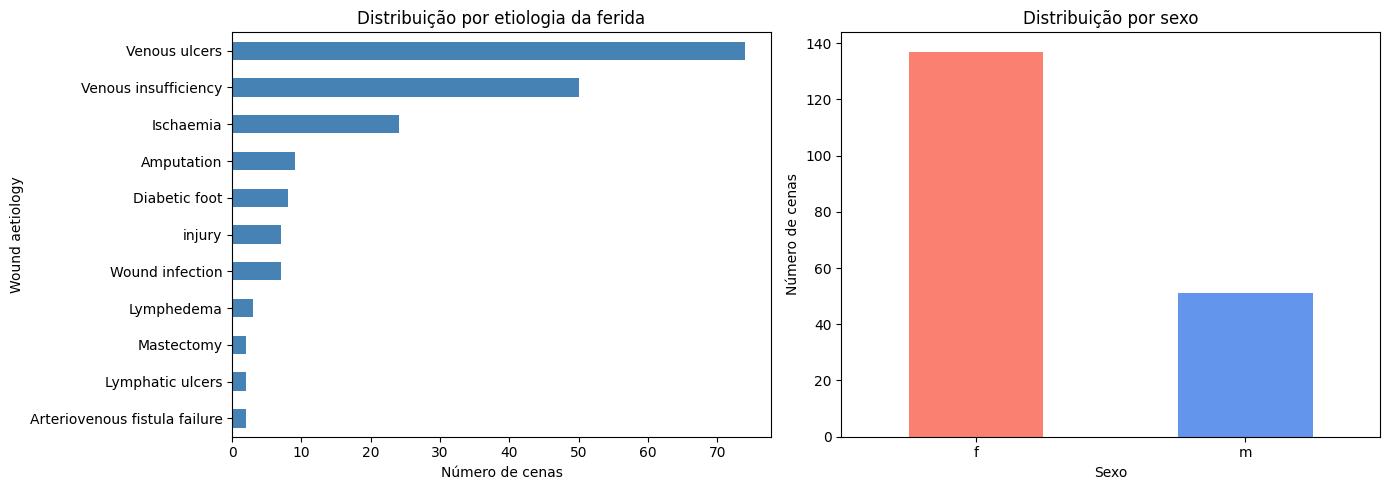

In [ ]:
# Gráfico de barras horizontais com a quantidade de cenas por etiologia da ferida,
# e gráfico de barras verticais com a distribuição por sexo.
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df["Wound aetiology"].value_counts().plot(kind="barh", ax=axs[0], color="steelblue")
axs[0].set_title("Distribuição por etiologia da ferida")
axs[0].set_xlabel("Número de cenas")
axs[0].invert_yaxis()  # mantém a etiologia mais frequente no topo

df["Sex"].value_counts().plot(kind="bar", ax=axs[1], color=["salmon", "cornflowerblue"])
axs[1].set_title("Distribuição por sexo")
axs[1].set_xlabel("Sexo")
axs[1].set_ylabel("Número de cenas")
axs[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

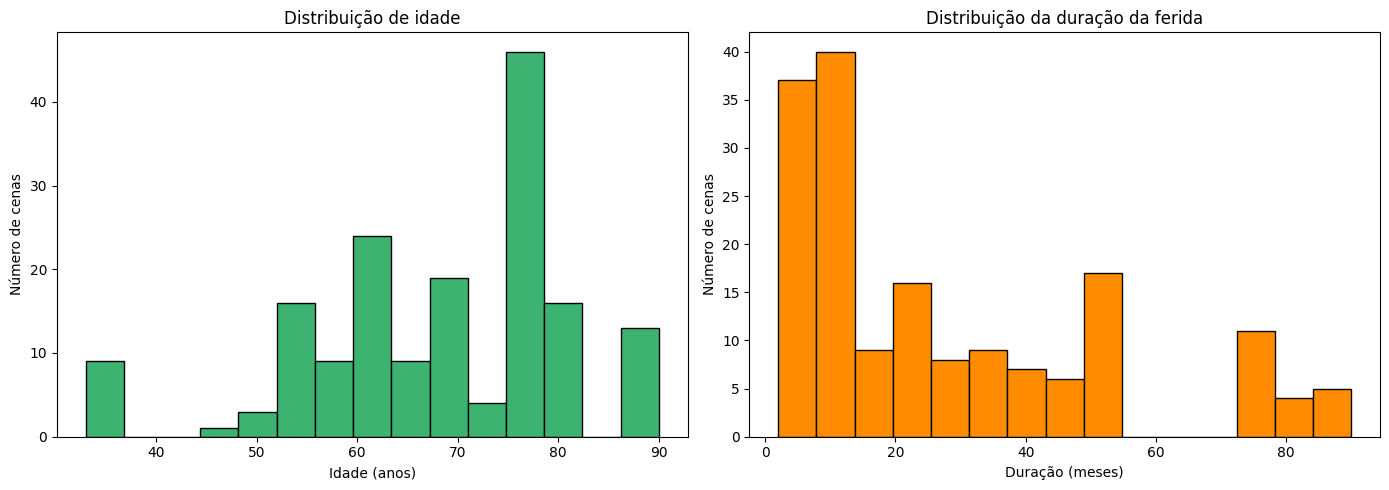

In [ ]:
# Histogramas da idade dos pacientes e da duração da ferida (em meses),
# ignorando valores ausentes (dropna).
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df["Age [year]"].dropna().plot(kind="hist", bins=15, ax=axs[0], color="mediumseagreen", edgecolor="black")
axs[0].set_title("Distribuição de idade")
axs[0].set_xlabel("Idade (anos)")
axs[0].set_ylabel("Número de cenas")

df["Duration [month]"].dropna().plot(kind="hist", bins=15, ax=axs[1], color="darkorange", edgecolor="black")
axs[1].set_title("Distribuição da duração da ferida")
axs[1].set_xlabel("Duração (meses)")
axs[1].set_ylabel("Número de cenas")

plt.tight_layout()
plt.show()

## 6. Disponibilidade de modalidades registradas no dataset (segundo o CSV)

Cada cena pode conter diferentes tipos de captura (foto RGB, máscara de segmentação, par estéreo, imagem térmica, profundidade e combinações entre elas). Aqui contamos, para cada modalidade, em quantas cenas ela está marcada como disponível no `description.csv` — isso é diferente de checar o que já está baixado localmente, o que fazemos na Seção 9.

In [ ]:
# Lista das colunas binárias que indicam disponibilidade de cada modalidade de imagem por cena.
modalidade_cols = ["Photo", "Mask", "Stereo_l", "Stereo_r", "Thermal", "Depth camera",
                    "Photo-thermal image", "Stereo map with photo-thermal image",
                    "Deep map with photo-thermal image"]

# Soma cada coluna binária: como os valores são 0/1, a soma equivale à contagem
# de cenas em que aquela modalidade está disponível.
print("Numero de cenas com cada modalidade disponivel (de", len(df), "cenas):")
print(df[modalidade_cols].sum())

Numero de cenas com cada modalidade disponivel (de 188 cenas):
Photo                                  188
Mask                                   188
Stereo_l                               184
Stereo_r                               183
Thermal                                188
Depth camera                           177
Photo-thermal image                     79
Stereo map with photo-thermal image     76
Deep map with photo-thermal image       74
dtype: int64


## 7. Pacientes com acompanhamento em mais de um dia (follow-up)

Alguns pacientes têm mais de uma visita registrada (follow-up da evolução da ferida ao longo do tempo). Aqui identificamos quantos pacientes têm apenas 1 dia de registro e quantos têm follow-up, além de quantos dias cada um tem.

In [ ]:
# Para cada paciente (case_id), conta quantos dias distintos de visita existem.
days_per_case = df.groupby("case_id")["day_id"].nunique()

print("Pacientes com apenas 1 dia:", (days_per_case == 1).sum())
print("Pacientes com mais de 1 dia (follow-up):", (days_per_case > 1).sum())
print()
print("Pacientes com follow-up e quantos dias cada um tem:")
print(days_per_case[days_per_case > 1].sort_values(ascending=False))

Pacientes com apenas 1 dia: 30
Pacientes com mais de 1 dia (follow-up): 17

Pacientes com follow-up e quantos dias cada um tem:
case_id
8     5
17    5
4     4
20    4
12    4
45    4
5     3
13    2
11    2
23    2
26    2
36    2
35    2
39    2
42    2
46    2
47    2
Name: day_id, dtype: int64


## 8. Subgrupo de interesse: úlceras venosas de perna

Para o projeto, o subgrupo de úlceras venosas é o de maior interesse. Aqui filtramos as cenas dessa etiologia, avaliamos quantos pacientes têm follow-up dentro desse subgrupo e salvamos o subconjunto em um CSV separado.

In [ ]:
# Filtra apenas as cenas cuja etiologia da ferida é úlcera/insuficiência venosa.
venous = df[df["Wound aetiology"].isin(["Venous ulcers", "Venous insufficiency"])].copy()
print(f"Cenas no subgrupo venoso: {len(venous)} de {venous['case_id'].nunique()} pacientes")

# Dentro do subgrupo venoso, verifica quantos pacientes têm mais de um dia de acompanhamento.
venous_days = venous.groupby("case_id")["day_id"].nunique()
print("Desses, com mais de 1 dia:", (venous_days > 1).sum())

# Salva o subconjunto venoso em um CSV separado, para uso nas próximas etapas do projeto.
venous.to_csv("/content/venous_subset.csv", index=False)
venous.head(10)

Cenas no subgrupo venoso: 124 de 31 pacientes
Desses, com mais de 1 dia: 12


,Path to files,Age [year],Sex,Treatment technique,Wound aetiology,Duration [month],Photo,Mask,Stereo_l,Stereo_r,Thermal,Depth camera,Photo-thermal image,Stereo map with photo-thermal image,Deep map with photo-thermal image,case_id,day_id,scene_id
0,patients\case_1\day_1\data\scene_1,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,8.0,1,1,1,1,1,1,1,1,1,1,1,1
3,patients\case_11\day_1\data\scene_1,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,24.0,1,1,1,1,1,0,1,1,1,11,1,1
4,patients\case_11\day_1\data\scene_2,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,24.0,1,1,1,1,1,0,0,0,0,11,1,2
5,patients\case_11\day_196\data\scene_1,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,31.0,1,1,1,1,1,1,1,1,1,11,196,1
6,patients\case_11\day_196\data\scene_2,67.0,f,Modern wound dressing and compression therapy,Venous insufficiency,31.0,1,1,1,1,1,1,0,0,0,11,196,2
7,patients\case_12\day_1\data\scene_1,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,8.0,1,1,1,1,1,1,1,1,1,12,1,1
8,patients\case_12\day_1\data\scene_2,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,8.0,1,1,1,1,1,1,0,0,0,12,1,2
9,patients\case_12\day_1\data\scene_3,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,8.0,1,1,1,1,1,1,0,0,0,12,1,3
10,patients\case_12\day_124\data\scene_1,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,12.0,1,1,1,1,1,1,1,1,1,12,124,1
11,patients\case_12\day_124\data\scene_2,82.0,m,Modern wound dressing and compression therapy,Venous ulcers,12.0,1,1,1,1,1,1,0,0,0,12,124,2


## 9. Quais cenas você já tem disponíveis localmente (`results/` e `patients/`)

O notebook confere, para cada linha do `description.csv`, se a pasta correspondente existe em `PATIENTS_DIR` (dados brutos) e/ou em `RESULTS_DIR` (dados processados). Isso dá visibilidade imediata do quanto do dataset já está pronto para uso, sem precisar contar manualmente.

In [ ]:
def to_patients_path(row) -> Path:
    # Monta o caminho da pasta "data/" (dados brutos/unprocessed) para uma linha do dataframe,
    # seguindo o padrão case_X/day_Y/data/scene_Z dentro de PATIENTS_DIR.
    return PATIENTS_DIR / f"case_{row['case_id']}" / f"day_{row['day_id']}" / "data" / f"scene_{row['scene_id']}"

def to_results_path(row) -> Path:
    # Monta o caminho equivalente dentro de RESULTS_DIR, onde a pasta "data" vira "results"
    # (é assim que o results.zip organiza os dados já processados de cada cena).
    return RESULTS_DIR / f"case_{row['case_id']}" / f"day_{row['day_id']}" / "results" / f"scene_{row['scene_id']}"

df["patients_path"] = df.apply(to_patients_path, axis=1)
df["results_path"] = df.apply(to_results_path, axis=1)
df["has_patients"] = df["patients_path"].apply(lambda p: p.exists())
df["has_results"] = df["results_path"].apply(lambda p: p.exists())

print(f"Cenas com dados brutos (patients/) disponíveis localmente:    {df['has_patients'].sum()} de {len(df)}")
print(f"Cenas com dados processados (results/) disponíveis localmente: {df['has_results'].sum()} de {len(df)}")

df[df["has_patients"]][["Path to files", "case_id", "day_id", "Wound aetiology"]]

Cenas com dados brutos (patients/) disponíveis localmente:    188 de 188
Cenas com dados processados (results/) disponíveis localmente: 0 de 188


,Path to files,case_id,day_id,Wound aetiology
0,patients\case_1\day_1\data\scene_1,1,1,Venous ulcers
1,patients\case_10\day_1\data\scene_1,10,1,Mastectomy
2,patients\case_10\day_1\data\scene_2,10,1,Mastectomy
3,patients\case_11\day_1\data\scene_1,11,1,Venous insufficiency
4,patients\case_11\day_1\data\scene_2,11,1,Venous insufficiency
...,...,...,...,...
183,patients\case_8\day_343\data\scene_2,8,343,Venous insufficiency
184,patients\case_9\day_1\data\scene_1,9,1,Venous insufficiency
185,patients\case_9\day_1\data\scene_2,9,1,Venous insufficiency
186,patients\case_9\day_1\data\scene_3,9,1,Venous insufficiency


## 10. Checando a estrutura real de pastas e lendo os dados brutos (`patients/`)

Antes de confiar cegamente no que o CSV diz, conferimos manualmente a estrutura real de uma cena no dataset bruto: como ela é organizada em subpastas por modalidade, onde ficam os arquivos de calibração das câmeras, e então lemos de fato o conteúdo dos arquivos — a máscara de segmentação, a escala real de temperatura (`thermal.csv`) e os blocos brutos do sensor de profundidade (`depth_camera_1.dat`).

In [ ]:
# Usa a primeira cena com dados brutos disponíveis localmente (calculada na seção anterior)
# como exemplo para checar a estrutura de pastas.
exemplos_patients = df[df["has_patients"]]

if len(exemplos_patients) > 0:
    row0 = exemplos_patients.iloc[0]
    folder0 = row0["patients_path"]
    print(folder0)
    print(sorted(p.name for p in folder0.iterdir()) if folder0.exists() else "PASTA NAO ENCONTRADA -- confira PATIENTS_DIR")
else:
    print("Nenhuma pasta local de patients/ encontrada ainda -- extraia patients.zip para ver esta seção.")

/content/patients_unprocessed/patients/patients/case_1/day_1/data/scene_1
['Thumbs.db', 'depth_camera', 'mask.png', 'photo.jpg', 'stereo_l.png', 'stereo_r.png', 'thermal.csv', 'thermal.png']


In [ ]:
# Lista o conteúdo da subpasta "depth_camera" dessa cena de exemplo,
# para ver como os arquivos de profundidade estão nomeados/organizados.
if len(exemplos_patients) > 0:
    print(sorted(p.name for p in (folder0 / "depth_camera").iterdir()))

['depth_camera_1.dat']


In [ ]:
# Os arquivos de calibração das câmeras ficam em uma pasta "calib" no nível do paciente/dia,
# fora da pasta "data" das cenas. Aqui localizamos essa pasta e listamos seu conteúdo
# (uma subpasta por cena, ex.: scene_1, scene_2).
if len(exemplos_patients) > 0:
    calib_folder = folder0.parent.parent / "calib"
    print(calib_folder)
    print(sorted(p.name for p in calib_folder.iterdir()) if calib_folder.exists() else "não achei nesse caminho")

/content/patients_unprocessed/patients/patients/case_1/day_1/calib
['scene_1', 'scene_2']


In [ ]:
# Confere o conteúdo da calibração de duas cenas (scene_1 e scene_2), para comparar
# se a estrutura de arquivos de parâmetros da câmera é a mesma entre cenas diferentes.
if len(exemplos_patients) > 0 and calib_folder.exists():
    print("scene_1:", sorted(p.name for p in (calib_folder / "scene_1").iterdir()))
    print("scene_2:", sorted(p.name for p in (calib_folder / "scene_2").iterdir()))

scene_1: ['depth_camera', 'photo.jpg', 'stereo_l.png', 'stereo_r.png', 'thermal.csv', 'thermal.png']
scene_2: ['depth_camera', 'photo.jpg', 'stereo_l.png', 'stereo_r.png', 'thermal.csv', 'thermal.png']


In [ ]:
def read_thermal_scale(scene_path: Path):
    """Lê o min/max de temperatura real usado para colorir o thermal.png (ex.: 'min;21.0;max;35.0')."""
    f = scene_path / "thermal.csv"
    if not f.exists():
        return None
    txt = f.read_text().strip().split(";")
    d = dict(zip(txt[0::2], txt[1::2]))
    return float(d["min"]), float(d["max"])

def read_depth_blocks(scene_path: Path):
    """Lê os blocos do depth_camera_1.dat: Distance, xVector, yVector, Amplitude, Confidence."""
    f = scene_path / "depth_camera" / "depth_camera_1.dat"
    if not f.exists():
        return None
    lines = f.read_text().splitlines()
    headers = [i for i, l in enumerate(lines) if l.startswith("%")]
    blocks = {}
    names = ["Distance", "xVector", "yVector", "Amplitude", "Confidence"]
    for name, start in zip(names, headers):
        nrows = 144
        rows = [list(map(float, lines[start + 1 + i].split("\t"))) for i in range(nrows)]
        blocks[name] = np.array(rows)
    return blocks

# Usando a mesma cena de exemplo (folder0): checa o tamanho do arquivo bruto de profundidade,
# confere se máscara e foto têm a mesma resolução, e lê a escala real de temperatura
# e os blocos de profundidade em metros (distância, X, Y, amplitude, confiança).
if len(exemplos_patients) > 0:
    import os
    dat_path = folder0 / "depth_camera" / "depth_camera_1.dat"
    if dat_path.exists():
        print("Tamanho do depth_camera_1.dat em bytes:", os.path.getsize(dat_path))

    mask = np.array(Image.open(folder0 / "mask.png").convert("L")) > 127
    photo = np.array(Image.open(folder0 / "photo.jpg").convert("RGB"))
    print(f"Case {row0['case_id']} — máscara: {mask.shape}, foto: {photo.shape[:2]} "
          f"(mesma resolução: {mask.shape == photo.shape[:2]})")

    escala_termica = read_thermal_scale(folder0)
    print(f"Escala real de temperatura (thermal.csv): min={escala_termica[0]}°C, max={escala_termica[1]}°C")

    blocos_prof = read_depth_blocks(folder0)
    print(f"Distância (m): min={np.nanmin(blocos_prof['Distance']):.3f}, "
          f"max={np.nanmax(blocos_prof['Distance']):.3f}, mean={np.nanmean(blocos_prof['Distance']):.3f}")
    print(f"Confiança da medição: min={blocos_prof['Confidence'].min():.0f}, max={blocos_prof['Confidence'].max():.0f}")
else:
    print("Nenhuma pasta de patients/ encontrada ainda — extraia patients.zip para ver esta seção.")

Tamanho do depth_camera_1.dat em bytes: 749853
Case 1 — máscara: (3264, 4896), foto: (3264, 4896) (mesma resolução: True)
Escala real de temperatura (thermal.csv): min=21.0°C, max=35.0°C
Distância (m): min=0.696, max=2.771, mean=1.186
Confiança da medição: min=0, max=127
